In [1]:
# ── Cell 1: Environment setup ─────────────────────────────────────────────────
# Installs all required packages and verifies GPU access.

import sys, subprocess, importlib
from pathlib import Path
from typing import Optional

print(">> Setting up environment...")

def ensure_package(pkg_name: str, import_name: Optional[str] = None):
    """Install a package if missing, then import it."""
    import_name = import_name or pkg_name
    try:
        importlib.import_module(import_name)
        print(f"   [OK] {import_name}")
    except ImportError:
        print(f"   [INSTALLING] {pkg_name}...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", pkg_name],
            stdout=subprocess.DEVNULL,
        )
        print(f"   [OK] {import_name} (just installed)")
    finally:
        globals()[import_name] = importlib.import_module(import_name)


# ── Check if CUDA torch is installed; if not, install it ─────────────────────
print(">> Checking PyTorch CUDA...")
try:
    import torch
    if not torch.cuda.is_available():
        print("   [!] CPU-only torch detected — installing CUDA build...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q",
            "torch", "torchvision",
            "--index-url", "https://download.pytorch.org/whl/cu128",
            "--force-reinstall",
        ])
        # Must invalidate cached import
        for mod_name in list(sys.modules.keys()):
            if mod_name == "torch" or mod_name.startswith("torch."):
                del sys.modules[mod_name]
        import torch
        print(f"   [OK] Reinstalled torch {torch.__version__} with CUDA {torch.version.cuda}")
    else:
        print(f"   [OK] torch {torch.__version__} — CUDA {torch.version.cuda}")
except ImportError:
    print("   [INSTALLING] torch + torchvision (CUDA 12.8)...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "torch", "torchvision",
        "--index-url", "https://download.pytorch.org/whl/cu128",
    ])
    import torch
    print(f"   [OK] torch {torch.__version__}")

# ── Core packages ─────────────────────────────────────────────────────────────
ensure_package("opencv-python", "cv2")
ensure_package("numpy", "numpy")
ensure_package("matplotlib", "matplotlib")
ensure_package("ultralytics", "ultralytics")

# lapx is needed for ByteTrack but isn't directly importable
try:
    importlib.import_module("lapx")
    print("   [OK] lapx")
except ImportError:
    print("   [INSTALLING] lapx...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "lapx"],
        stdout=subprocess.DEVNULL,
    )
    print("   [OK] lapx (just installed)")

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\n{'='*50}")
print(f"  Project root : {PROJECT_ROOT}")
print(f"  Models dir   : {MODELS_DIR}")
print(f"  CUDA available: {torch.cuda.is_available()}")
print(f"  Device       : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU          : {torch.cuda.get_device_name(0)}")
print(f"{'='*50}")
print("\n>> Environment ready!")

>> Setting up environment...
>> Checking PyTorch CUDA...
   [OK] torch 2.10.0+cu128 — CUDA 12.8
   [OK] cv2
   [OK] numpy
   [OK] matplotlib
   [OK] ultralytics
   [INSTALLING] lapx...
   [OK] lapx (just installed)

  Project root : g:\Projects\Code\Image processing\women-face-blur
  Models dir   : g:\Projects\Code\Image processing\women-face-blur\models
  CUDA available: True
  Device       : cuda
  GPU          : NVIDIA GeForce RTX 3050 Laptop GPU

>> Environment ready!


In [2]:
# ── Cell 2: Load YOLOv8 segmentation model ────────────────────────────────────

from ultralytics import YOLO

print(">> Loading YOLOv8m-seg model...")

MODEL_PATH = MODELS_DIR / "yolov8m-seg.pt"

if not MODEL_PATH.exists():
    print("   [DOWNLOADING] YOLOv8m-seg weights (first run only, ~50 MB)...")
    tmp_model = YOLO("yolov8m-seg.pt")  # auto-downloads to ultralytics cache
    import shutil
    cached = Path(tmp_model.ckpt_path)
    shutil.copy2(cached, MODEL_PATH)
    print(f"   [OK] Saved to {MODEL_PATH}")
else:
    print(f"   [OK] Found existing weights: {MODEL_PATH.name}")

print(f"   Loading model onto {DEVICE}...")
model = YOLO(str(MODEL_PATH))
model.to(DEVICE)

print(f"\n>> Model ready!")
print(f"   Model : {MODEL_PATH.name}")
print(f"   Device: {next(model.model.parameters()).device}")

>> Loading YOLOv8m-seg model...
   [OK] Found existing weights: yolov8m-seg.pt
   Loading model onto cuda...

>> Model ready!
   Model : yolov8m-seg.pt
   Device: cuda:0


In [3]:
# ── Cell 3: Person detection & tracking utilities ─────────────────────────────

from typing import List, Dict, Tuple
import time

print(">> Defining person detection & tracking functions...")


def track_persons_frame(
    frame_bgr: np.ndarray,
    conf: float = 0.4,
    tracker: str = "bytetrack.yaml",
) -> List[Dict]:
    """Run YOLOv8-seg with tracking. Returns list of person dicts with track IDs + masks."""
    results = model.track(
        frame_bgr,
        classes=[0],        # class 0 = person in COCO
        conf=conf,
        persist=True,       # keep tracks across frames
        tracker=tracker,
        verbose=False,
    )
    r = results[0]
    persons: List[Dict] = []
    if r.boxes is None or len(r.boxes) == 0:
        return persons

    ids = r.boxes.id
    for i in range(len(r.boxes)):
        box = r.boxes.xyxy[i].cpu().numpy().astype(int)
        confidence = float(r.boxes.conf[i])
        track_id = int(ids[i]) if ids is not None else -1
        mask = r.masks.data[i].cpu().numpy() if r.masks is not None else None
        persons.append({
            "box": tuple(box),
            "confidence": confidence,
            "track_id": track_id,
            "mask": mask,
        })
    return persons


print("   [OK] track_persons_frame() — detect + track all persons with segmentation masks")
print("\n>> Utilities loaded.")

>> Defining person detection & tracking functions...
   [OK] track_persons_frame() — detect + track all persons with segmentation masks

>> Utilities loaded.


In [4]:
# ── Cell 4: Blur utilities ─────────────────────────────────────────────────────

from typing import Set

print(">> Defining blur functions...")


def blur_person_mask(
    frame: np.ndarray,
    mask: np.ndarray,
    ksize: Tuple[int, int] = (99, 99),
    sigma: float = 0,
) -> np.ndarray:
    """Blur ONLY the pixels inside the segmentation mask (pixel-accurate body blur)."""
    h, w = frame.shape[:2]
    mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
    mask_bool = mask_resized > 0.5
    blurred = cv2.GaussianBlur(frame, ksize, sigma)
    result = frame.copy()
    result[mask_bool] = blurred[mask_bool]
    return result


def blur_person_box(
    frame: np.ndarray,
    box: Tuple[int, int, int, int],
    ksize: Tuple[int, int] = (99, 99),
    sigma: float = 0,
    padding: float = 0.1,
) -> np.ndarray:
    """Fallback: blur a rectangular bounding-box region (when mask unavailable)."""
    h, w = frame.shape[:2]
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    x1, y1 = max(0, int(x1 - padding * bw)), max(0, int(y1 - padding * bh))
    x2, y2 = min(w, int(x2 + padding * bw)), min(h, int(y2 + padding * bh))
    result = frame.copy()
    roi = result[y1:y2, x1:x2]
    if roi.size > 0:
        result[y1:y2, x1:x2] = cv2.GaussianBlur(roi, ksize, sigma)
    return result


print("   [OK] blur_person_mask() — pixel-accurate body blur via segmentation mask")
print("   [OK] blur_person_box()  — fallback rectangular blur")
print("\n>> Blur utilities ready.")

>> Defining blur functions...
   [OK] blur_person_mask() — pixel-accurate body blur via segmentation mask
   [OK] blur_person_box()  — fallback rectangular blur

>> Blur utilities ready.


>> Opening video for diagnostic scan...
   Video: 1920x1080 @ 25.0 fps — 1210 frames
>> Running person tracking on first frames to stabilize IDs...
   Frame   0: 16 persons — IDs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
   Frame  30: 16 persons — IDs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 19, 13]
   Frame  60: 17 persons — IDs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 13, 17, 15, 18]
   Frame  90: 16 persons — IDs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14, 13, 17, 15, 18]
>> Scanned 91 frames.

  All unique track IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

>> NOW: look at the images above, identify the 2 women's IDs,
   then set  WOMEN_TRACK_IDS = {id1, id2}  in the next cell.


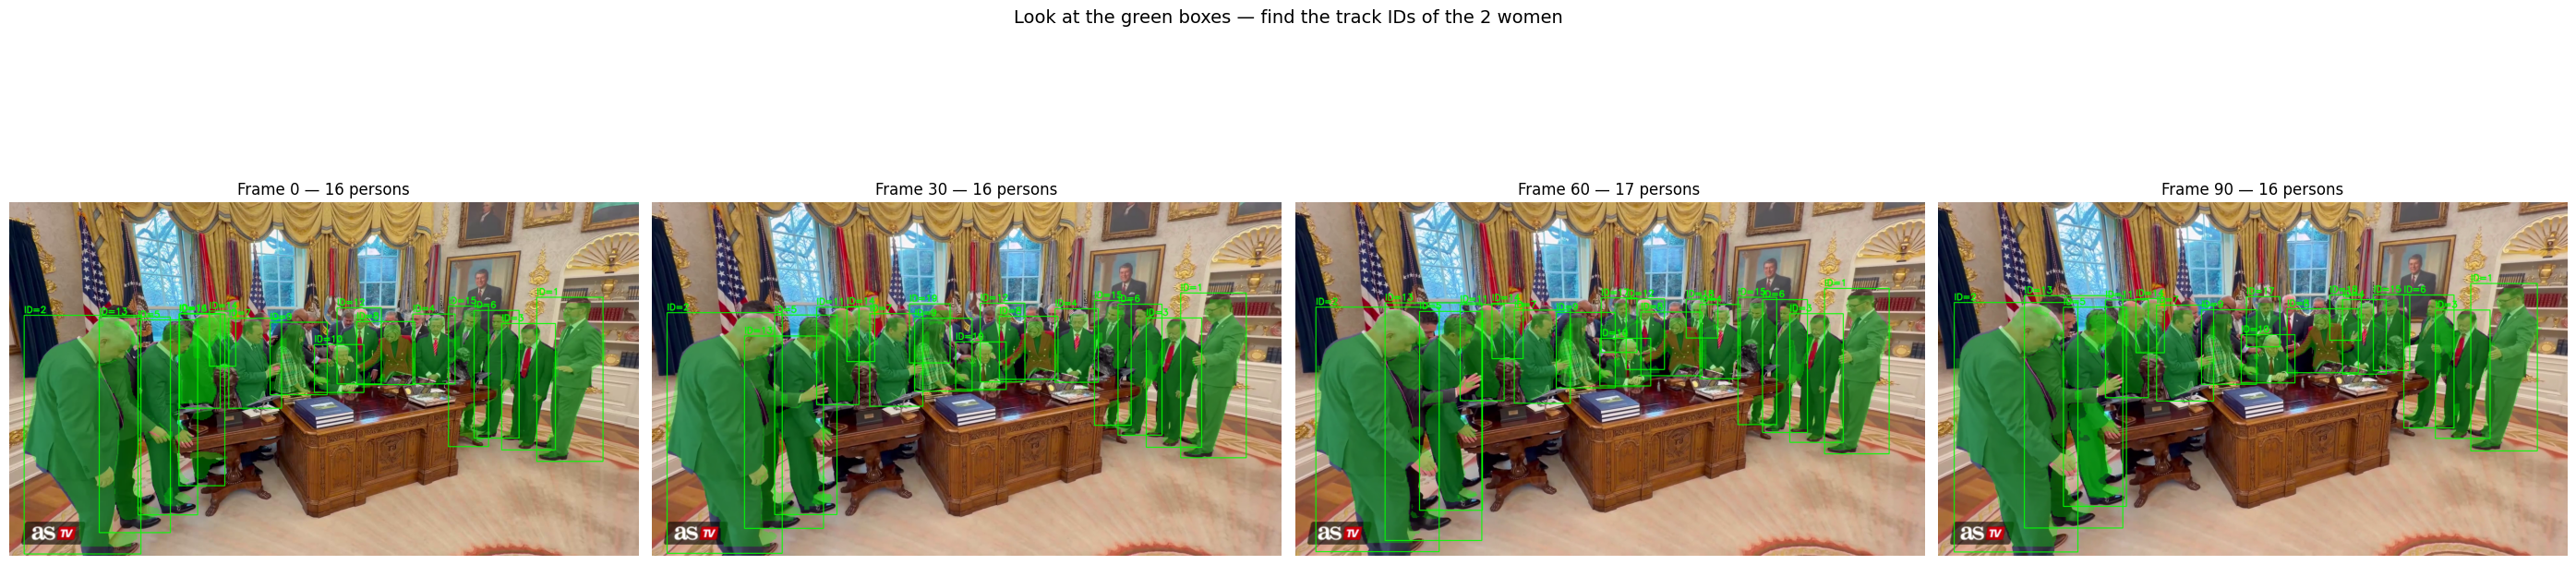

In [5]:
# ── Cell 5: Diagnostic — identify track IDs for the 2 women ──────────────────
# Run this cell, inspect the images, note down which track IDs belong to women,
# then set WOMEN_TRACK_IDS in Cell 6.

VIDEO_INPUT_PATH = PROJECT_ROOT / "ovaloffice.mp4"

# Reset tracker so IDs start fresh
model.predictor = None

print(">> Opening video for diagnostic scan...")
cap = cv2.VideoCapture(str(VIDEO_INPUT_PATH))
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: {VIDEO_INPUT_PATH}")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
w_vid = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h_vid = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"   Video: {w_vid}x{h_vid} @ {fps:.1f} fps — {total_frames} frames")

# Scan first ~90 frames, sample a few for visualization
SAMPLE_FRAMES = [0, 30, 60, 90]
sample_images = {}
frame_idx = 0

print(">> Running person tracking on first frames to stabilize IDs...")
while True:
    ret, frame = cap.read()
    if not ret or frame_idx > max(SAMPLE_FRAMES):
        break
    persons = track_persons_frame(frame, conf=0.35)
    if frame_idx in SAMPLE_FRAMES:
        sample_images[frame_idx] = (frame.copy(), list(persons))
        print(f"   Frame {frame_idx:>3d}: {len(persons)} persons — IDs = {[p['track_id'] for p in persons]}")
    frame_idx += 1

cap.release()
print(f">> Scanned {frame_idx} frames.")

# Display sample frames with track IDs and mask overlays
n = len(sample_images)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 8))
if n == 1:
    axes = [axes]

for ax, (fnum, (frm, pers)) in zip(axes, sample_images.items()):
    vis = frm.copy()
    for p in pers:
        x1, y1, x2, y2 = p["box"]
        tid = p["track_id"]
        label = f"ID={tid}"
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(vis, label, (x1, max(0, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2, cv2.LINE_AA)
        if p.get("mask") is not None:
            mask_r = cv2.resize(p["mask"], (vis.shape[1], vis.shape[0]),
                                interpolation=cv2.INTER_NEAREST)
            overlay = vis.copy()
            overlay[mask_r > 0.5] = (0, 255, 0)
            vis = cv2.addWeighted(vis, 0.7, overlay, 0.3, 0)

    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {fnum} — {len(pers)} persons")
    ax.axis("off")

plt.suptitle("Look at the green boxes — find the track IDs of the 2 women", fontsize=14)
plt.tight_layout()

# Summary table
all_ids = set()
for fnum, (frm, pers) in sample_images.items():
    for p in pers:
        all_ids.add(p["track_id"])

print(f"\n{'='*50}")
print(f"  All unique track IDs: {sorted(all_ids)}")
print(f"{'='*50}")
print(f"\n>> NOW: look at the images above, identify the 2 women's IDs,")
print(f"   then set  WOMEN_TRACK_IDS = {{id1, id2}}  in the next cell.")

In [6]:
# ── Cell 6: Process video — blur women's full bodies + keep audio ─────────────

import time, tempfile
from moviepy import VideoFileClip

VIDEO_INPUT_PATH  = PROJECT_ROOT / "ovaloffice.mp4"
VIDEO_OUTPUT_PATH = PROJECT_ROOT / "ovaloffice_women_blurred.mp4"

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Track IDs of the 2 women (from Cell 5 diagnostic output)                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
WOMEN_TRACK_IDS: Set[int] = {8, 9}

# ── Tunable parameters ───────────────────────────────────────────────────────
PERSON_CONF    = 0.35
BLUR_KSIZE     = (99, 99)
TRACKER_CONFIG = "bytetrack.yaml"

# Reset tracker so IDs match diagnostic
model.predictor = None

cap = cv2.VideoCapture(str(VIDEO_INPUT_PATH))
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: {VIDEO_INPUT_PATH}")

fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Write blurred frames to a temp file first (OpenCV can't handle audio)
temp_video = PROJECT_ROOT / "_temp_no_audio.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(str(temp_video), fourcc, fps, (width, height))

frame_idx = 0
blurred_count = 0
t0 = time.time()

print(f"{'='*60}")
print(f"  Video processing started")
print(f"  Input  : {VIDEO_INPUT_PATH.name}")
print(f"  Output : {VIDEO_OUTPUT_PATH.name}")
print(f"  Size   : {width}x{height} @ {fps:.1f} fps — {total} frames")
print(f"  Blurring track IDs: {sorted(WOMEN_TRACK_IDS)}")
print(f"  Device : {DEVICE}")
print(f"{'='*60}\n")

# ── Step 1: Process frames (blur women) ──────────────────────────────────────
while True:
    ret, frame = cap.read()
    if not ret:
        break

    persons = track_persons_frame(frame, conf=PERSON_CONF, tracker=TRACKER_CONFIG)

    result = frame.copy()
    frame_blur_count = 0
    for p in persons:
        if p["track_id"] in WOMEN_TRACK_IDS:
            if p.get("mask") is not None:
                result = blur_person_mask(result, p["mask"], ksize=BLUR_KSIZE)
            else:
                result = blur_person_box(result, p["box"], ksize=BLUR_KSIZE)
            frame_blur_count += 1
            blurred_count += 1

    out.write(result)
    frame_idx += 1

    if frame_idx % 50 == 0 or frame_idx == 1:
        elapsed = time.time() - t0
        pct = frame_idx / total * 100
        fps_actual = frame_idx / elapsed if elapsed > 0 else 0
        eta = (elapsed / frame_idx) * (total - frame_idx) if frame_idx > 0 else 0
        filled = int(30 * frame_idx / total)
        bar = "█" * filled + "░" * (30 - filled)
        print(f"  [{bar}] {pct:5.1f}%  frame {frame_idx}/{total}  "
              f"{fps_actual:.1f} fps  ETA {eta:.0f}s  "
              f"(blurred {frame_blur_count} in this frame)")

cap.release()
out.release()

elapsed_blur = time.time() - t0
print(f"\n  Blur pass done: {frame_idx} frames in {elapsed_blur:.1f}s "
      f"({frame_idx / elapsed_blur:.1f} fps)")

# ── Step 2: Merge audio from original video ──────────────────────────────────
print(f"\n>> Restoring audio from original video...")

video_clip = VideoFileClip(str(temp_video))
original_clip = VideoFileClip(str(VIDEO_INPUT_PATH))

if original_clip.audio is not None:
    final_clip = video_clip.with_audio(original_clip.audio)
    final_clip.write_videofile(
        str(VIDEO_OUTPUT_PATH),
        codec="libx264",
        audio_codec="aac",
        logger=None,
    )
    final_clip.close()
    print(f"   [OK] Audio merged successfully")
else:
    # No audio in original — just rename temp file
    import shutil
    shutil.move(str(temp_video), str(VIDEO_OUTPUT_PATH))
    print(f"   [!] Original video has no audio track")

video_clip.close()
original_clip.close()

# Clean up temp file
if temp_video.exists():
    temp_video.unlink()

total_time = time.time() - t0
print(f"\n{'='*60}")
print(f"  ALL DONE!")
print(f"  Frames processed     : {frame_idx}")
print(f"  Person-frames blurred: {blurred_count}")
print(f"  Total time           : {total_time:.1f}s")
print(f"  Output (with audio)  : {VIDEO_OUTPUT_PATH}")
print(f"{'='*60}")

  Video processing started
  Input  : ovaloffice.mp4
  Output : ovaloffice_women_blurred.mp4
  Size   : 1920x1080 @ 25.0 fps — 1210 frames
  Blurring track IDs: [8, 9]
  Device : cuda

  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   0.1%  frame 1/1210  1.9 fps  ETA 625s  (blurred 2 in this frame)
  [█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   4.1%  frame 50/1210  3.4 fps  ETA 343s  (blurred 2 in this frame)
  [██░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   8.3%  frame 100/1210  3.4 fps  ETA 329s  (blurred 2 in this frame)
  [███░░░░░░░░░░░░░░░░░░░░░░░░░░░]  12.4%  frame 150/1210  3.4 fps  ETA 312s  (blurred 2 in this frame)
  [████░░░░░░░░░░░░░░░░░░░░░░░░░░]  16.5%  frame 200/1210  3.4 fps  ETA 300s  (blurred 2 in this frame)
  [██████░░░░░░░░░░░░░░░░░░░░░░░░]  20.7%  frame 250/1210  3.3 fps  ETA 287s  (blurred 2 in this frame)
  [███████░░░░░░░░░░░░░░░░░░░░░░░]  24.8%  frame 300/1210  3.3 fps  ETA 275s  (blurred 2 in this frame)
  [████████░░░░░░░░░░░░░░░░░░░░░░]  28.9%  frame 350/1210  3.3 fps  ETA 261s  (blurred 2 i